In [1]:
#define the neural network architecture for the policy and value function with python and jax
from flax import linen as nn


import torch
from torch import nn
from torch.utils.data import DataLoader


import mujoco
from IPython.display import clear_output

from mujoco_playground._src.locomotion.pendulum_inverse_pendulum.environment import DoublePendulumEnv

import numpy as np
import pyinstrument

import jax
import jax.dlpack
import torch.utils.dlpack
import seaborn as sns 
import jax.numpy as jp
import os
import imageio.v2 as imageio

import matplotlib.pyplot as plt
import torch
from tensordict.nn import TensorDictModule
from tensordict.nn.distributions import NormalParamExtractor
from torch import nn
#from torchrl.collectors import SyncDataCollector
from torchrl.data.replay_buffers import ReplayBuffer
from torchrl.data.replay_buffers.samplers import SamplerWithoutReplacement
from torchrl.data.replay_buffers.storages import LazyTensorStorage
from torchrl.envs import (Compose, DoubleToFloat, ObservationNorm, StepCounter,
                          TransformedEnv)
from torchrl.envs.libs.gym import GymEnv
from torchrl.envs.utils import check_env_specs, ExplorationType, set_exploration_type
from torchrl.modules import ProbabilisticActor, TanhNormal, ValueOperator
from torchrl.objectives import ClipPPOLoss
from torchrl.objectives.value import GAE
from tqdm import tqdm
import random



device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cpu device


In [2]:

model = mujoco.MjModel.from_xml_path(
    "mujoco_playground/_src/locomotion/pendulum_inverse_pendulum/xmls/pendulum_inverse_pendulum.xml"
)
print(model.nq, model.nv, model.nu)  # should print your joint/actuator counts

2 2 1


In [3]:



def get_data_using_agent(env, agent, iterations, verbose=False):
    episode_length = env._config.episode_length
    batched_reset = jax.vmap(env.reset)
    batched_step  = jax.vmap(env.step)

    seed = int(np.random.randint(0, 2**31 - 1))
    rng = jax.random.PRNGKey(seed)
    keys = jax.random.split(rng, iterations)
    state = batched_reset(keys)
    state = jax.block_until_ready(state)

    observations, raw_actions_list, rewards_list, dones_list, values_list, log_probs_list, qpos_list = [], [], [], [], [], [], []

    for frame_idx in range(episode_length):
        if verbose and frame_idx % 50 == 0:
            print(f"Frame {frame_idx+1}/{episode_length}")
        
        state = jax.block_until_ready(state)
        observation = prepare_observation_for_NN(state.obs)
        with torch.no_grad():
            action, raw_action, log_prob, value = agent.choose_action(observation)

        state = batched_step(state, action)

        observations.append(observation.detach().numpy())
        raw_actions_list.append(np.asarray(raw_action))
        rewards_list.append(state.reward)      # keep as device array, no sync yet
        dones_list.append(state.done)          # keep as device array, no sync yet
        values_list.append(value)
        log_probs_list.append(log_prob)
        qpos_list.append(np.asarray(state.data.qpos[env._joint_qids]))

    # single bulk sync at the end instead of one per frame
    observations = np.stack(observations, axis=1)
    raw_actions  = np.stack(raw_actions_list, axis=1)
    rewards      = np.asarray(jp.stack(rewards_list, axis=1))
    dones        = np.asarray(jp.stack(dones_list, axis=1))
    values       = np.stack(values_list, axis=1)
    log_probs    = np.stack(log_probs_list, axis=1)
    qpos_history = np.stack(qpos_list, axis=1)

    return observations, raw_actions,  rewards, dones, values, log_probs, qpos_history




def prepare_observation_for_NN(observation):    return torch.from_dlpack(observation).float()

In [4]:
from distro import name
from torch import dist


def init_layer(layer, std=np.sqrt(2), bias_const=0.0): #implementation detail 2.
    nn.init.orthogonal_(layer.weight, std)
    nn.init.constant_(layer.bias, bias_const)
    return layer


class PolicyNet(nn.Module):
    def __init__(self, input_shape, action_dim):
        super().__init__()
        self.input_shape = input_shape
        self.action_dim = action_dim
        self.gamma = 0.99
        
        self.base = nn.Sequential(
            init_layer(nn.Linear(self.input_shape, 64)),
            nn.Tanh(),
            init_layer(nn.Linear(64, 64)),          
            nn.Tanh(),
        )
        self.mean = init_layer(nn.Linear(64, action_dim), std=0.01)
        self.log_std = nn.Parameter(torch.zeros(action_dim))  # std starts at exp(0) = 1
        self.value = init_layer(nn.Linear(64, 1), std=1.0)         #value head

    def forward(self, x):
        base_out = self.base(x)
        mean  = self.mean(base_out)
        
        std = torch.clamp(self.log_std.exp(), min=1e-3)
        value = self.value(base_out).squeeze(-1)
        dist = torch.distributions.Normal(mean, std)   
        return dist, value
    
   
class Agent:
    def __init__(self,env, n_actions, gamma=0.99, lr=3e-4, policy_clip=0.2, batch_size=64, N=500, n_epochs=10, gae_lambda=0.95):
        self.gamma = gamma
        self.lr = lr
        self.env = env
        self.n_actions = n_actions
        self.policy_clip = policy_clip
        self.batch_size = batch_size
        self.N = N
        self.n_epochs = n_epochs
        self.gae_lambda = gae_lambda
        self.policy = PolicyNet(env._config.input_shape, env._config.action_dim).to(device)
        self.optimizer = torch.optim.Adam(self.policy.parameters(), lr=self.lr, eps=1e-5)
        self.policy = torch.compile(self.policy)  # Compile the policy network for performance
        self.best_reward = -float('inf')
        self.training_results = {'policy_loss': [], 'critic_loss': [], 'entropy_loss': [], 'total_loss': [],
                                'average_reward': [], "states": [], "actions": [], "rewards": [],
                                "dones": [], "values": [], "log_probs": [], "advantages": [],
                                "update_ratios": [], "dist": [], "kl_ratio": [], "v_clipfrac": [],
                                "raw_returns": []}
        for name, p in self.policy.named_parameters():
            print(name, p.shape, p.requires_grad)


    def save_model(self):
        torch.save(self.policy.state_dict(), os.path.join("models", f'PPO_policy_{round(self.best_reward, 3):.3f}.pth'))
        torch.save(self.optimizer.state_dict(), os.path.join("models", f'PPO_optimizer_{round(self.best_reward, 3):.3f}.pth'))

    def save_replay(self, states, rollout_idx=0, path=None, fps=None, width=800, height=800):
        if fps is None:
            fps = int(1/self.env._config.ctrl_dt)
        if path is None:
            os.makedirs("models", exist_ok=True)
            path = os.path.join("models", f"replay_rollout_{rollout_idx}_{round(self.best_reward, 3):.3f}.mp4")

        if isinstance(states, torch.Tensor):
            rollout_batch = states.detach().cpu().numpy()
        else:
            rollout_batch = np.asarray(states)

        if rollout_batch.ndim == 3:
            if rollout_batch.shape[0] == 0:
                print("Replay video not saved because the rollout batch is empty.")
                return
            rollout_idx = min(int(rollout_idx), rollout_batch.shape[0] - 1)
            rollout = rollout_batch[rollout_idx]
        elif rollout_batch.ndim == 2:
            rollout = rollout_batch
        else:
            print("Replay video not saved because the state shape is not supported.")
            return

        def draw_line(img, p0, p1, color=(70, 70, 70), thickness=3):
            x0, y0 = p0
            x1, y1 = p1
            dx, dy = x1 - x0, y1 - y0
            steps = max(abs(int(dx)), abs(int(dy)), 1)
            for i in range(steps + 1):
                x = int(round(x0 + dx * i / steps))
                y = int(round(y0 + dy * i / steps))
                for ox in range(-thickness, thickness + 1):
                    for oy in range(-thickness, thickness + 1):
                        if 0 <= x + ox < width and 0 <= y + oy < height:
                            img[y + oy, x + ox] = color

        def draw_circle(img, center, radius=6, color=(20, 20, 20)):
            x0, y0 = center
            for y in range(max(0, int(y0) - radius), min(height, int(y0) + radius + 1)):
                for x in range(max(0, int(x0) - radius), min(width, int(x0) + radius + 1)):
                    if (x - x0) ** 2 + (y - y0) ** 2 <= radius ** 2:
                        img[y, x] = color

        frames = []
        for step in rollout:
            img = np.full((height, width, 3), 220, dtype=np.uint8)
            q = np.asarray(step, dtype=np.float32).reshape(-1)
            if q.size >= 2:
                if self.env is not None and hasattr(self.env, "_get_link_positions"):
                    pivot, p1, p2, tip = self.env._get_link_positions(q)
                else:
                    q1, q2 = float(q[0]), float(q[1])
                    pivot = np.array([0.0, 0.0, 0.0], dtype=np.float32)
                    p1 = pivot + np.array([-np.sin(q1), 0.0, -np.cos(q1)], dtype=np.float32) * 0.5
                    p2 = p1 + np.array([-np.sin(q1 + q2), 0.0, -np.cos(q1 + q2)], dtype=np.float32) * 0.5
                    tip = p2 + np.array([-np.sin(q1 + q2), 0.0, -np.cos(q1 + q2)], dtype=np.float32) * 0.5

                points = [
                    (float(pivot[0]), float(pivot[2])),
                    (float(p1[0]), float(p1[2])),
                    (float(p2[0]), float(p2[2])),
                    (float(tip[0]), float(tip[2])),
                ]

                coords = []
                for x, z in points:
                    px = int(np.clip((x + 1.0) * 0.5 * (width - 1), 0, width - 1))
                    py = int(np.clip((1.0 - (z + 1.0) * 0.5) * (height - 1), 0, height - 1))
                    coords.append((px, py))

                draw_line(img, coords[0], coords[1], color=(25, 95, 175), thickness=3)
                draw_line(img, coords[1], coords[2], color=(220, 90, 45), thickness=3)
                #draw_line(img, coords[2], coords[3], color=(220, 90, 45), thickness=3)
                draw_circle(img, coords[0], radius=6, color=(0, 0, 0))
                draw_circle(img, coords[1], radius=5, color=(0, 0, 0))
                draw_circle(img, coords[2], radius=5, color=(0, 0, 0))
                #draw_circle(img, coords[3], radius=5, color=(0, 0, 0))

            frames.append(img)

        if len(frames) > 1:
            imageio.mimsave(path, frames, fps=fps)
            print(f"Saved replay video to {path}")
        else:
            print("Replay video not saved because not enough frames were collected.")


    def load_model(self, path_policy, path_optimizer):
        self.policy.load_state_dict(torch.load(path_policy))
        self.optimizer.load_state_dict(torch.load(path_optimizer))

    def choose_action(self, observation):
        state = torch.tensor(observation, dtype=torch.float).to(device)
        dist, value = self.policy(state)
        raw_action = dist.sample()

        squashed = torch.tanh(raw_action)  # scale to [-1, 1]
        log_prob = dist.log_prob(raw_action).sum(dim=-1) - torch.log1p(-squashed.pow(2) + 1e-6).sum(dim=-1)
                
                

        #scale the action to be within the action space bounds
        low = torch.tensor(self.env._lowers, dtype=torch.float32, device=device)
        high = torch.tensor(self.env._uppers, dtype=torch.float32, device=device)
        action = low + (high - low) * 0.5*(squashed + 1.0)

        
        
        return action.cpu().detach().numpy(), raw_action.cpu().detach().numpy(), log_prob.cpu().detach().numpy(), value.cpu().detach().numpy()

    def compute_gae(self, rewards, values, dones):    #general advantage estimation
        # rewards, values, dones: shape (iterations, episode_length)
        iterations, T = rewards.shape
        advantages = np.zeros((iterations, T), dtype=np.float32)
        last_gae = np.zeros(iterations, dtype=np.float32)

        for t in reversed(range(T - 1)):  
            delta = rewards[:, t] + self.gamma * values[:, t + 1] * (1 - dones[:, t]) - values[:, t]
            last_gae = delta + self.gamma * self.gae_lambda * (1 - dones[:, t]) * last_gae
            advantages[:, t] = last_gae

        return advantages


    def plot_results(self, training_results):
        if len(training_results["rewards"]) == 0:
            return
        clear_output(wait=True)

        fig = plt.figure(figsize=(23, 20))

        plt.subplot(3, 2, 1)
        plt.plot(training_results['policy_loss'])
        plt.title('Policy Loss')

        plt.subplot(3, 2, 2)
        plt.plot(training_results['critic_loss'])
        plt.title('Critic Loss')

        plt.subplot(3, 2, 3)
        plt.plot(training_results['entropy_loss'])
        plt.title('Entropy Loss')

        plt.subplot(3, 2, 4)
        plt.plot(training_results['total_loss'])
        plt.title('Total Loss')

        plt.subplot(3, 2, 5)
    
        
        reward_means = np.mean(training_results['rewards'], axis=1)  # shape: (n_runs,)
    

        window = 100  #number of rolluts

        n_chunks = len(reward_means) // window
        trimmed = reward_means[:n_chunks * window]
        chunks = trimmed.reshape(n_chunks, window)  # shape: (n_chunks, window)

        mean_reward  = chunks.mean(axis=1)   # avg over the rollouts in each chunk
        best_reward  = chunks.max(axis=1)    # best rollout in each chunk
        worst_reward = chunks.min(axis=1)    # worst rollout in each chunk

        x = np.arange(n_chunks) * window * env._config.episode_length  # rollout index at start of each chunk

        
        plt.plot(x, mean_reward, label='Average Reward', color='C0')
        plt.fill_between(x, worst_reward, best_reward,
                        color='C0', alpha=0.2,
                        label=f'Best/worst rollout range (per {window} rollouts)')
        plt.title('Average Reward')
        plt.xlabel('Steps')
        plt.ylabel('Average Reward')
        plt.legend()



        #plt.subplot(3, 2, 6)
        update_ratios_dict = {}
        for dictionary in training_results['update_ratios']:  
            
            for layer_name in dictionary:
                if layer_name not in update_ratios_dict:
                    update_ratios_dict[layer_name] = [dictionary[layer_name]]
                else:
                    update_ratios_dict[layer_name].append(dictionary[layer_name])
                
        

        # --- plot ---
        start_from = 10   # set to 10 only once you've confirmed lengths support it
        fig, ax = plt.subplots(figsize=(23, 8))

        for name, values in update_ratios_dict.items():
            v = values[start_from:]
            x = list(range(len(v)))
            label=str(name)[1:]
            if "bias" not in label:
                line, = ax.plot(x, v, label=str(name)[1:],alpha=0.5)

        
        #ax.title('Policy Loss')

        ax.set_xlabel("step")
        ax.set_ylabel("update/weight ratio")
        ax.set_yscale("log")
        ax.legend(loc="best")
        fig.tight_layout()
        plt.show()


        plt.tight_layout()
        plt.show()

    def PPO_step(self, batch, max_grad_norm = 0.5, keep_training_results=False, max_kl=999, clip_vloss=False, vf_clip_coef=0.2): #max_kl=0.04      999 as disabled
        states, raw_action, old_log_probs, normalized_advantages, old_values, returns = batch

        dist, values = self.policy(states)

        if keep_training_results:
            self.training_results["dist"].append(dist)
            

        squashed = torch.tanh(raw_action)  # scale to [-1, 1]
        new_log_probs = dist.log_prob(raw_action).sum(dim=-1) - torch.log1p(-squashed.pow(2) + 1e-6).sum(dim=-1)
        
        
        
        log_ratio = new_log_probs - old_log_probs      
        prob_ratio = log_ratio.exp()


        #how much policy changed in this episode! Schulman's estimator
        approx_kl = (prob_ratio - 1 - log_ratio).mean().item()
        v_clipfrac = ((values - old_values).abs() > vf_clip_coef).float().mean().item()
        if approx_kl > max_kl:
            return torch.tensor(0.0), torch.tensor(0.0), torch.tensor(0.0), torch.tensor(0.0), approx_kl, v_clipfrac  # Return zero losses if KL divergence exceeds threshold



        weighted_probs =          normalized_advantages * prob_ratio
        weighted_clipped_probs =  normalized_advantages * torch.clamp(prob_ratio, 1 - self.policy_clip, 1 + self.policy_clip) 
        
        policy_loss = -torch.min(weighted_probs, weighted_clipped_probs).mean()

        #clipped value loss, as in OpenAI's Spinning Up implementation
        if clip_vloss:
            v_loss_unclipped = (values - returns) ** 2
            v_clipped = old_values + torch.clamp(values - old_values, -vf_clip_coef, vf_clip_coef)
            v_loss_clipped = (v_clipped - returns) ** 2
            v_loss_max = torch.max(v_loss_unclipped, v_loss_clipped)
            critic_loss = v_loss_max.mean()
        else:
            critic_loss = ((values - returns) ** 2).mean() 

        entropy_loss = dist.entropy().mean()
        
        
        total_loss = policy_loss + 0.5*critic_loss - 0.01*entropy_loss

        self.optimizer.zero_grad()
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.policy.parameters(), max_norm=max_grad_norm)  #clip gradients so they dont explode
        self.optimizer.step()


        return policy_loss, critic_loss, entropy_loss, total_loss, approx_kl, v_clipfrac  #just return the losses for logging purposes

    def keep_training_results_function(self, states=None, actions=None, rewards=None, advantages=None, policy_loss=None,
                                        critic_loss=None, entropy_loss=None, total_loss=None, dones=None, old_values=None,
                                        update_ratios=None, dist=None, kl_ratio=None, v_clipfrac=None, returns=None):
        
        with torch.no_grad():
            if policy_loss is not None:
                self.training_results['policy_loss'].append(policy_loss.item())
            if critic_loss is not None:
                self.training_results['critic_loss'].append(critic_loss.item())
            if entropy_loss is not None:
                self.training_results['entropy_loss'].append(entropy_loss.item())
            if total_loss is not None:
                self.training_results['total_loss'].append(total_loss.item())
            if rewards is not None:
                self.training_results['average_reward'].append(rewards.mean().item())
            if states is not None:
                self.training_results['states'].append(states)
            if actions is not None:
                self.training_results['actions'].append(actions)
            if rewards is not None:
                if len(self.training_results['rewards']) == 0:
                    self.training_results['rewards'] = rewards
                else:
                    self.training_results['rewards'] = np.concatenate( [self.training_results['rewards'], rewards], axis=0)
            if dones is not None:
                self.training_results['dones'].append(dones)
            if old_values is not None:
                self.training_results['values'].append(old_values)
            if advantages is not None:
                self.training_results['advantages'].append(advantages)
            if update_ratios is not None:
                self.training_results['update_ratios'].append(update_ratios)
            if dist is not None:
                self.training_results['dist'].append(dist)
            if kl_ratio is not None:
                self.training_results['kl_ratio'].append(kl_ratio)
            if v_clipfrac is not None:
                self.training_results['v_clipfrac'].append(v_clipfrac)
            if returns is not None:
                self.training_results['raw_returns'].append(returns)


    
    def learn(self, iterations = None, n_epochs = None, env=None,verbose=False, minibatch_size=None, paralel_envs=None, keep_training_results=False, show_progress=False, save_models=True, kl_threshold=0.04, vf_clip_coef=0.2):
        for iteration_idx in range(iterations):
            #profiler = pyinstrument.Profiler()
            #profiler.start()

            if show_progress:
                self.plot_results(self.training_results)
            if verbose:
                print(f"Iteration {iteration_idx+1}/{iterations}")
            
            states, raw_actions, rewards, dones, old_values, old_log_probs, qpos_history = get_data_using_agent(env, self, paralel_envs, verbose=verbose)
            advantages = self.compute_gae(rewards, old_values, dones)

            if save_models:
                new_reward = float(np.concatenate(rewards, 0).mean().item())
                if new_reward > self.best_reward:
                    self.best_reward = new_reward
                    self.save_model()
                    self.save_replay(qpos_history, rollout_idx=0)

                    if verbose:
                        print(f"Saved model with {new_reward} average reward!")

            if keep_training_results:
                self.keep_training_results_function(states=states, rewards=rewards, actions=raw_actions, old_values=old_values)

            #flatten for simpler acces and turn in to torch tensors
            states = torch.tensor(np.concatenate(states, 0), dtype=torch.float32, device=device)
            raw_actions = torch.tensor(np.concatenate(raw_actions, 0), dtype=torch.float32, device=device)
            old_log_probs = torch.tensor(np.concatenate(old_log_probs, 0), dtype=torch.float32, device=device)
            advantages = torch.tensor(np.concatenate(advantages, 0), dtype=torch.float32, device=device)
            old_values = torch.tensor(np.concatenate(old_values, 0), dtype=torch.float32, device=device)
            returns = torch.tensor(advantages + old_values, dtype=torch.float32, device=device)  # raw returns, compute BEFORE normalizing
            
                   
            normalized_advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)   # normalize advantages
            #normalized_advantages = np.clip(normalized_advantages, -10, 10) # could help?
            kl_ratio = 0.0;

            if keep_training_results:
                self.keep_training_results_function(advantages=normalized_advantages, returns=returns)
            
            

            
            for ppo_epoch in range(n_epochs):

                #policy changed too much
                if kl_ratio > kl_threshold:
                    break
                
                batches = DataLoader(list(zip(states, raw_actions, old_log_probs, normalized_advantages, old_values, returns)), batch_size=minibatch_size, shuffle=True)
                
                for batch in batches:
                    
                    
                    if keep_training_results:
                        # snapshot before the step
                        weights_old = {name: p.detach().clone() for name, p in self.policy.named_parameters()}
                    else:
                        update_ratios = None
                    
                    policy_loss, critic_loss, entropy_loss, total_loss, kl_ratio, v_clipfrac  = self.PPO_step(batch, keep_training_results=keep_training_results, max_kl=kl_threshold, clip_vloss=True, vf_clip_coef=0.2)

                    #policy changed too much
                    if kl_ratio > kl_threshold:
                        break

                    if keep_training_results: #weights update ratios metric should be around 1e-3
                        update_ratios = {}
                        for name, p in self.policy.named_parameters():
                            delta = (p.detach() - weights_old[name]).norm()
                            param_norm = weights_old[name].norm()
                            update_ratios[name] = (delta / (param_norm + 1e-12)).item()

                    
                    if keep_training_results:
                        self.keep_training_results_function(policy_loss=policy_loss, critic_loss=critic_loss, entropy_loss=entropy_loss, total_loss=total_loss, update_ratios=update_ratios, kl_ratio=kl_ratio, v_clipfrac=v_clipfrac)
                       
            

                
            #profiler.stop()
            #profiler.write_html("profile.html")




In [5]:
env = DoublePendulumEnv(config_overrides={"task": "swingup"})   #test env
print(env._config.input_shape, env._config.action_dim)

8 1


In [6]:
agent = Agent(env,env._config.action_dim,N=10, lr=3e-4)  #test agent 3e-4
print(agent.policy.input_shape, agent.policy.action_dim)
agent.choose_action(torch.zeros(env._config.input_shape).to(device))  # test forward pass

_orig_mod.log_std torch.Size([1]) True
_orig_mod.base.0.weight torch.Size([64, 8]) True
_orig_mod.base.0.bias torch.Size([64]) True
_orig_mod.base.2.weight torch.Size([64, 64]) True
_orig_mod.base.2.bias torch.Size([64]) True
_orig_mod.mean.weight torch.Size([1, 64]) True
_orig_mod.mean.bias torch.Size([1]) True
_orig_mod.value.weight torch.Size([1, 64]) True
_orig_mod.value.bias torch.Size([1]) True
8 1


/tmp/ipykernel_233122/4100730168.py:159: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  state = torch.tensor(observation, dtype=torch.float).to(device)


(array([0.03388655], dtype=float32),
 array([0.5894186], dtype=float32),
 array(-0.763662, dtype=float32),
 array(0., dtype=float32))

In [7]:

episode_length = env._config.episode_length
print(env._lowers)

[-0.064]


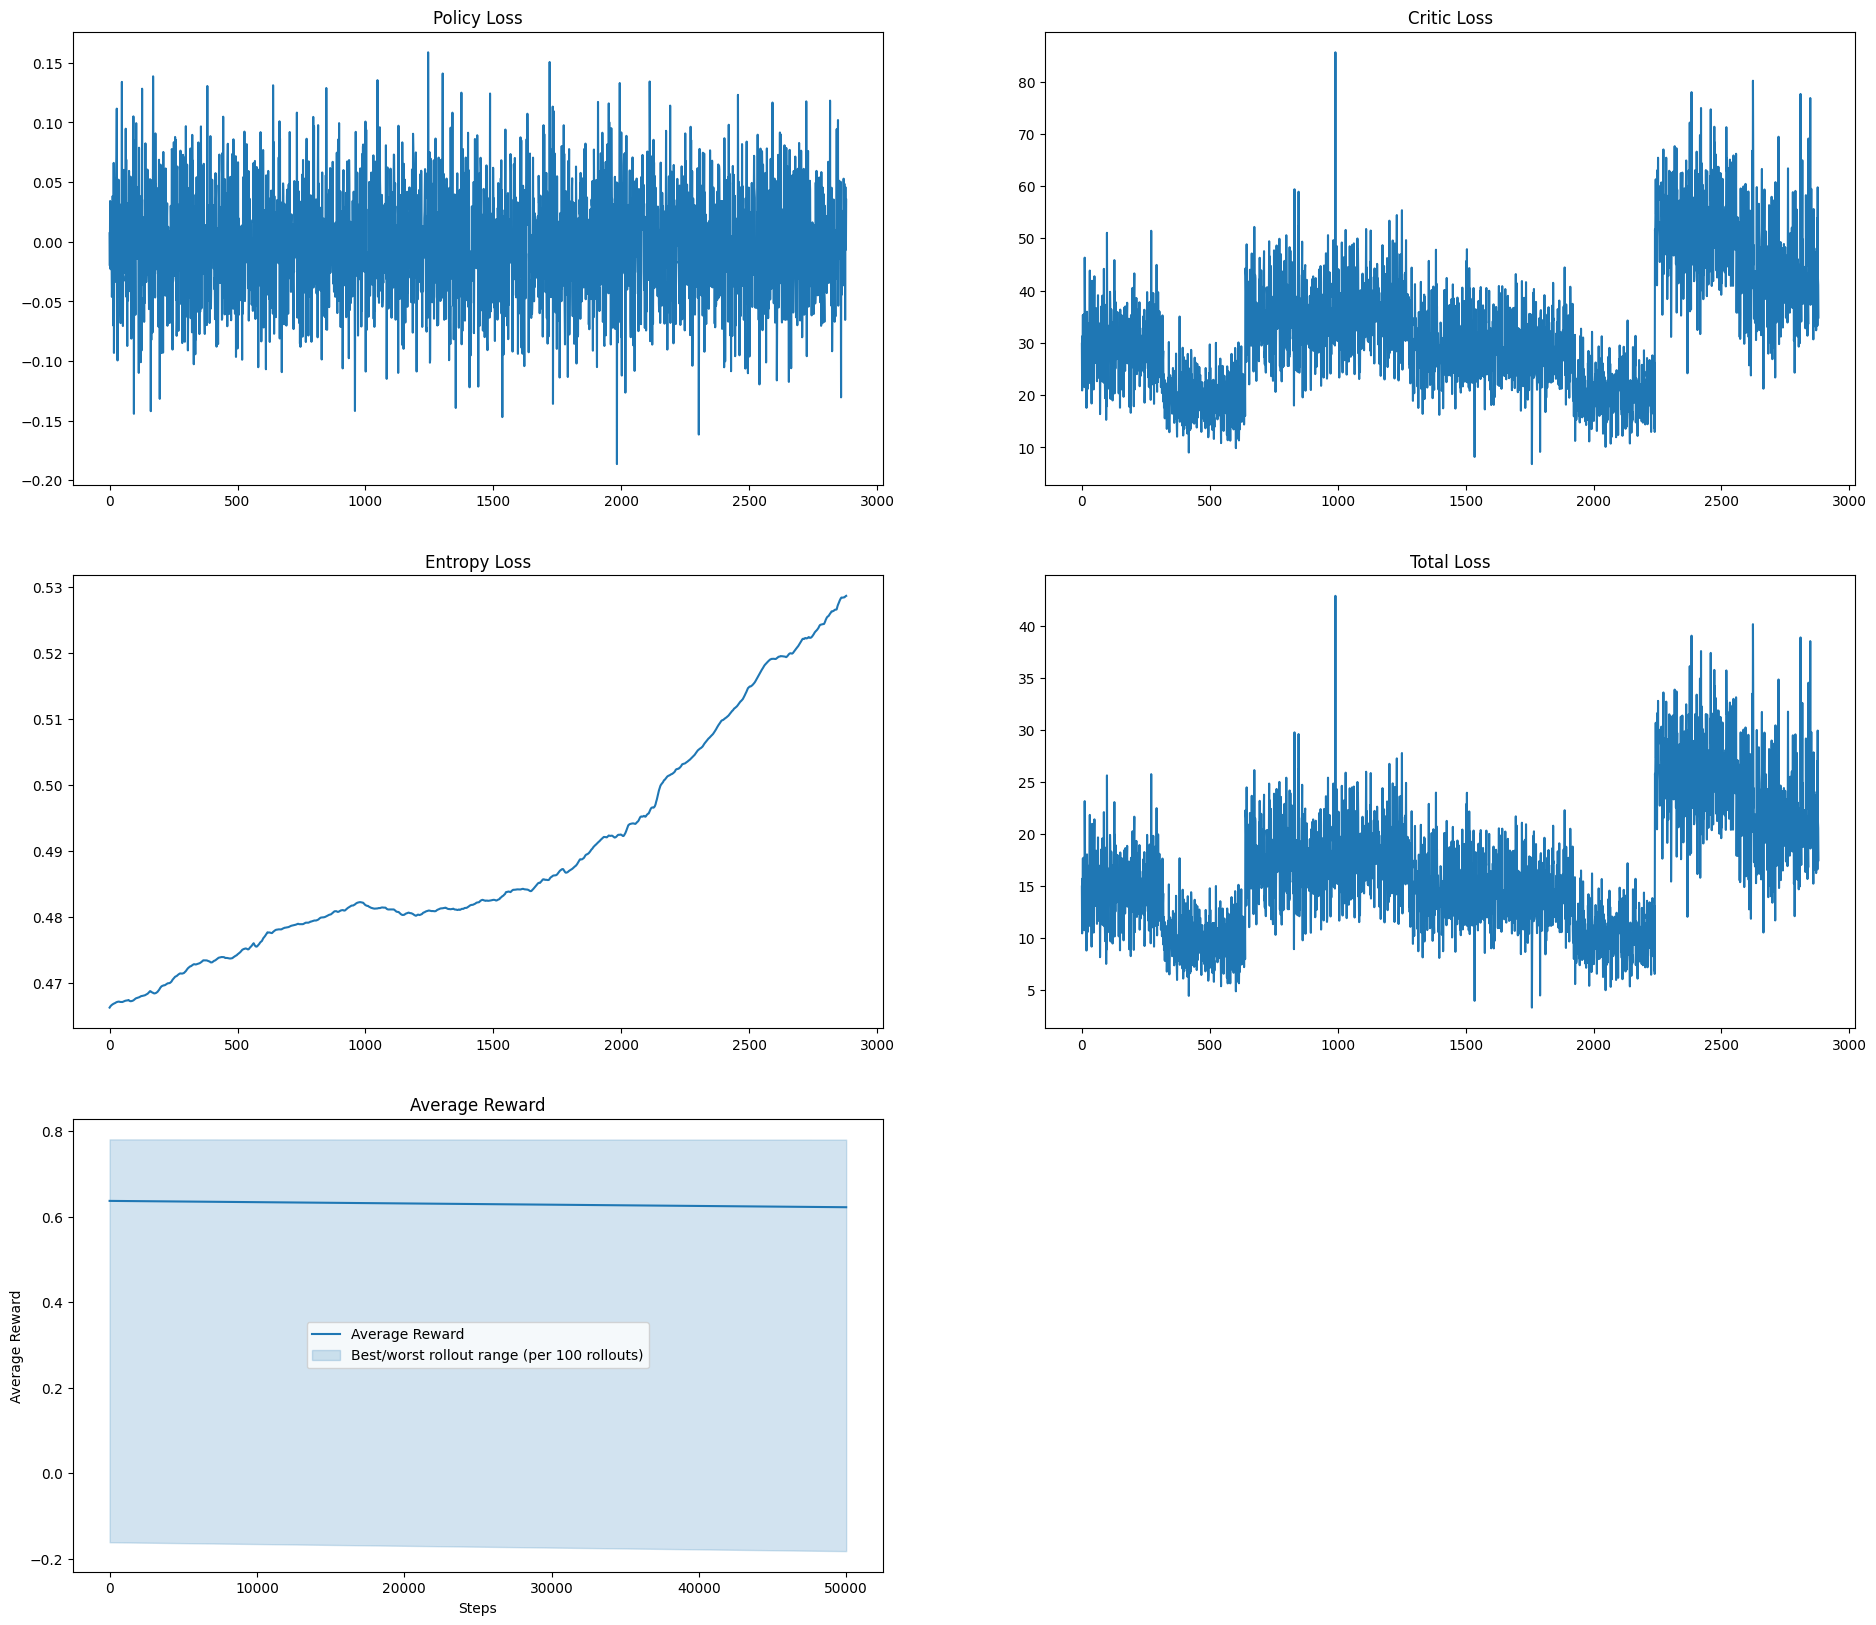

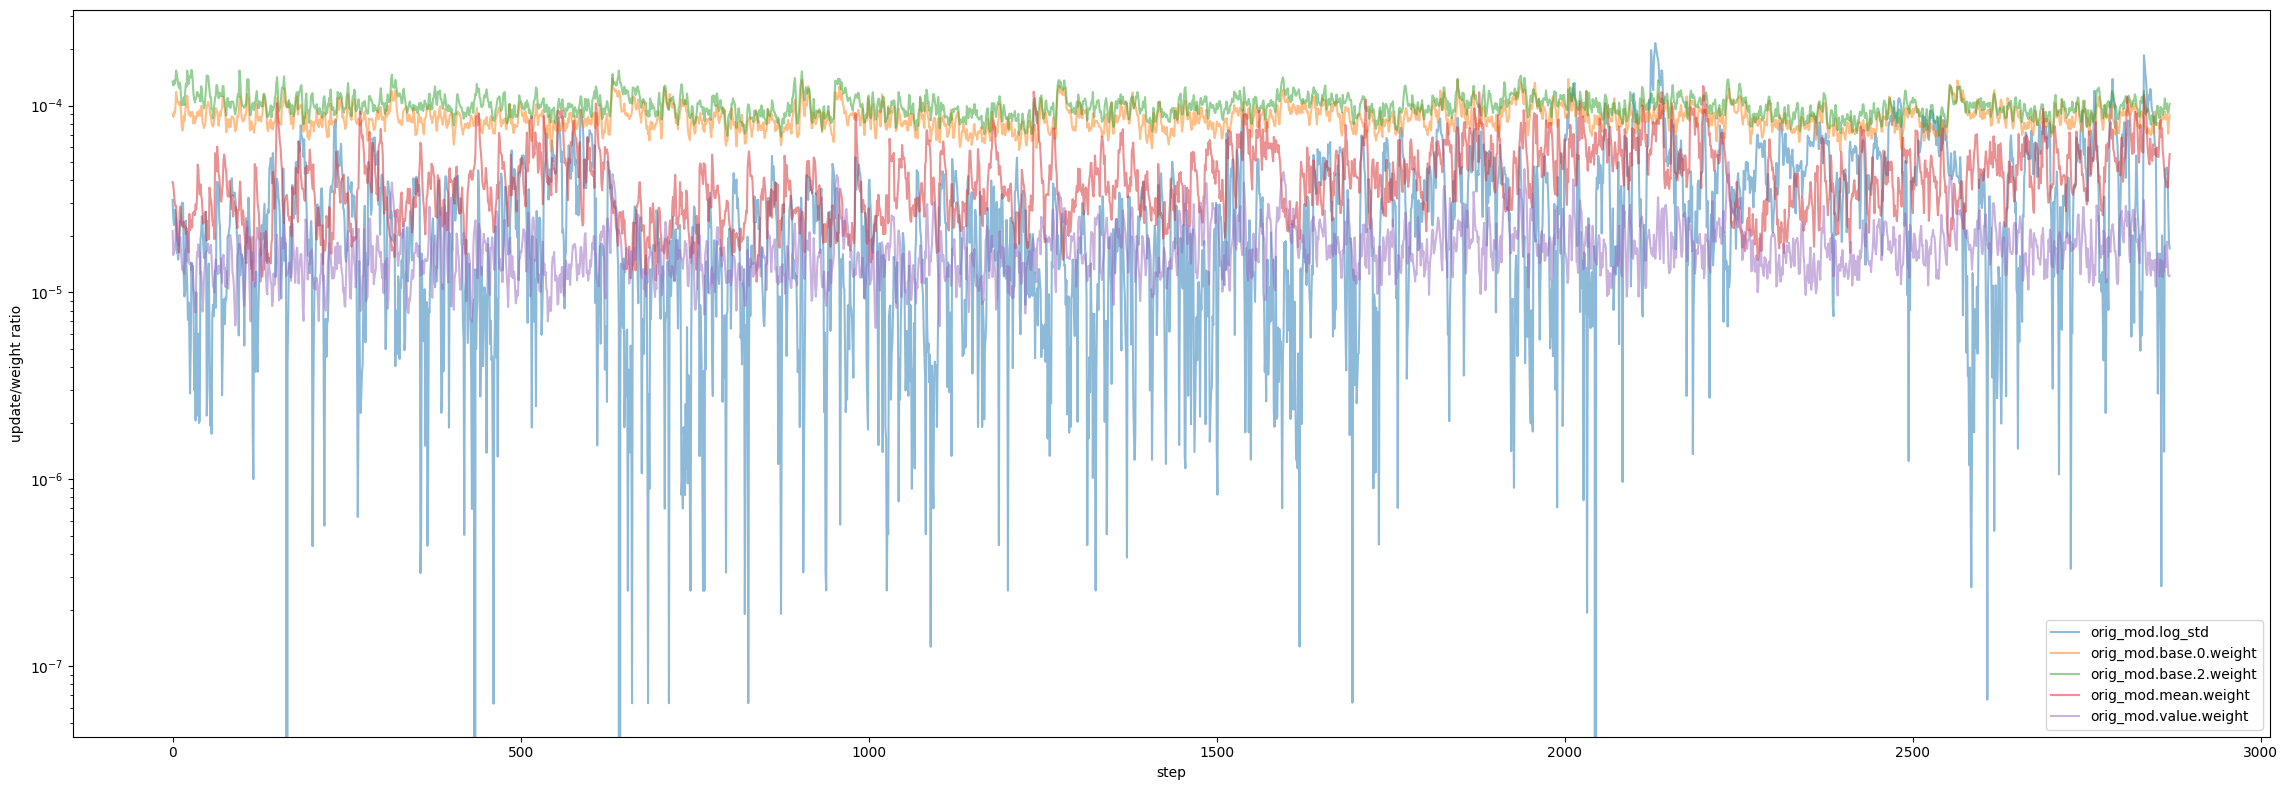

<Figure size 640x480 with 0 Axes>

Iteration 10/4000
Frame 1/500
Frame 51/500
Frame 101/500
Frame 151/500
Frame 201/500
Frame 251/500
Frame 301/500
Frame 351/500
Frame 401/500
Frame 451/500


In [ ]:
#training loop
paralel_envs = 32
iterations = 4000 #150

minibatch_size = 512     #dont go smaller than 512
n_epochs = 10 #4-10
print(f"number of minibathces per epoch: {(paralel_envs*env._config.episode_length)//minibatch_size}")


kl_threshold = 0.04  # threshold for early stopping if policy changes too much
vf_clip_coef = 0.2  # coefficient for clipping value function updates #normaly 0.2 

agent.load_model("models/PPO_policy_0.769.pth", "models/PPO_optimizer_0.769.pth")

agent.learn(env=env,iterations=iterations, n_epochs=n_epochs, minibatch_size=minibatch_size, paralel_envs=paralel_envs,
            verbose=True, keep_training_results=True, show_progress=True, kl_threshold=kl_threshold, save_models=True,
            vf_clip_coef=vf_clip_coef)



In [ ]:
training_results = agent.training_results
actions = np.concatenate(training_results['actions'], axis=0).mean(axis=2).mean(axis=1)
Rewards = training_results['rewards'].mean(axis=1)
advantages = [tensor.detach().cpu().numpy() for tensor in training_results['advantages']]
advantages = np.concatenate(advantages, axis=0)
policy_loss = training_results['policy_loss']
kl_ratio = training_results['kl_ratio']
v_clipfrac = training_results['v_clipfrac']
values = np.concatenate(training_results['values'], axis=0)
values = np.concatenate(values, axis=0)
print(values.shape, advantages.shape)
returns = values + advantages
raw_returns = np.concatenate(training_results['raw_returns'], axis=0)

training_results = agent.training_results

update_ratios_dict = {}
for dictionary in training_results['update_ratios']:
    for layer_name in dictionary:
        if layer_name not in update_ratios_dict:
            update_ratios_dict[layer_name] = [dictionary[layer_name]]
        else:
            update_ratios_dict[layer_name].append(dictionary[layer_name])

plt.close('all')

start_from = 10
fig, ax = plt.subplots(figsize=(16, 9))

for name, values in update_ratios_dict.items():
    v = values[start_from:]
    x = list(range(len(v)))
    label = str(name)[1:]
    if "weight" in label:
        ax.plot(x, v, label=str(name)[1:], alpha=0.5)

ax.set_xlabel("step")
ax.set_ylabel("update/weight ratio")
ax.set_yscale("log")
ax.legend(loc="best")
fig.tight_layout()
plt.show()

In [ ]:
def moving_average(x, window):
    return np.convolve(x, np.ones(window)/window, mode='valid')

def block_average(x, block_size):
    n_blocks = len(x) // block_size
    trimmed = x[:n_blocks * block_size]
    blocks = trimmed.reshape(n_blocks, block_size)
    return blocks.mean(axis=1)

In [ ]:
m = max(policy_loss)
v_clipfrac = moving_average(v_clipfrac, 100)
sns.lineplot([m*i for i in v_clipfrac], alpha=0.5)
sns.lineplot([10*i for i in kl_ratio], alpha=0.5)
sns.lineplot([0 for i in range(len(kl_ratio))])
sns.lineplot(policy_loss, alpha=0.5)


block_size = len(advantages)//len(policy_loss)
advantages_avg = block_average(advantages, block_size)
#sns.lineplot(advantages_avg, alpha=0.5)

In [ ]:



window = 1000
policy_loss_avg = moving_average(policy_loss, window)

block_size = len(advantages)//len(policy_loss_avg)
print(advantages.shape, len(policy_loss))

advantages_avg = block_average(advantages, block_size)

advantages_avg = moving_average(advantages_avg, window)


returns_avg = block_average(raw_returns, block_size)

returns_avg = moving_average(returns_avg, 10)

sns.lineplot(returns_avg)
sns.lineplot(policy_loss_avg)
#sns.lineplot(advantages_avg)
sns.lineplot([0 for _ in range(len(policy_loss_avg))])

In [ ]:
plt.figure(figsize=(23,15))
#sns.lineplot(x=range(len(advantages)), y=advantages, alpha=0.3, label='raw')
sns.lineplot(x=range(window-1, len(advantages)), y=ma, label=f'MA({window})')
sns.lineplot(x=range(len(advantages)), y=[0]*len(advantages), color='gray', linestyle='--')
plt.legend()
plt.show()